In [1]:
# Fix: fastai2 is obsolete/incompatible in this environment and triggers a NumPy import crash.
# Use fastai (supported) and add missing base imports used throughout the notebook.
import os
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd

from fastai.vision.all import *



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
path = Path("/kaggle/input/plant-pathology-2020-fgvc7")



In [3]:
train_df = pd.read_csv(path / "train.csv")
train_df.head()



,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,1,0
1,Train_1,1,0,0,0
2,Train_2,0,0,1,0
3,Train_3,1,0,0,0
4,Train_4,0,0,1,0


In [4]:
train_df.query("image_id == 'Train_5'")



,image_id,healthy,multiple_diseases,rust,scab
5,Train_5,0,0,0,1


In [5]:
get_image_files(path / "images")[5]



Path('/kaggle/input/plant-pathology-2020-fgvc7/images/Test_88.jpg')

In [6]:
train_df.iloc[0, 1:][train_df.iloc[0, 1:] == 1].index[0]



'rust'

In [7]:
LABEL_COLS = ["healthy", "multiple_diseases", "rust", "scab"]




In [8]:
def get_data(size=224):
    return DataBlock(
        blocks=(ImageBlock, CategoryBlock),
        get_x=ColReader(0, pref=path / "images", suff=".jpg"),
        get_y=lambda o: o.iloc[1:][o.iloc[1:] == 1].index[0],
        splitter=RandomSplitter(seed=42),
        item_tfms=Resize(size),
        batch_tfms=aug_transforms(flip_vert=True),
    )




In [9]:
dblock = get_data()



In [10]:
dsets = dblock.datasets(train_df)
dsets.train[0]



/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


(PILImage mode=RGB size=2048x1365, TensorCategory(3))

In [11]:
BS = (1024 - 256) // 8



/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


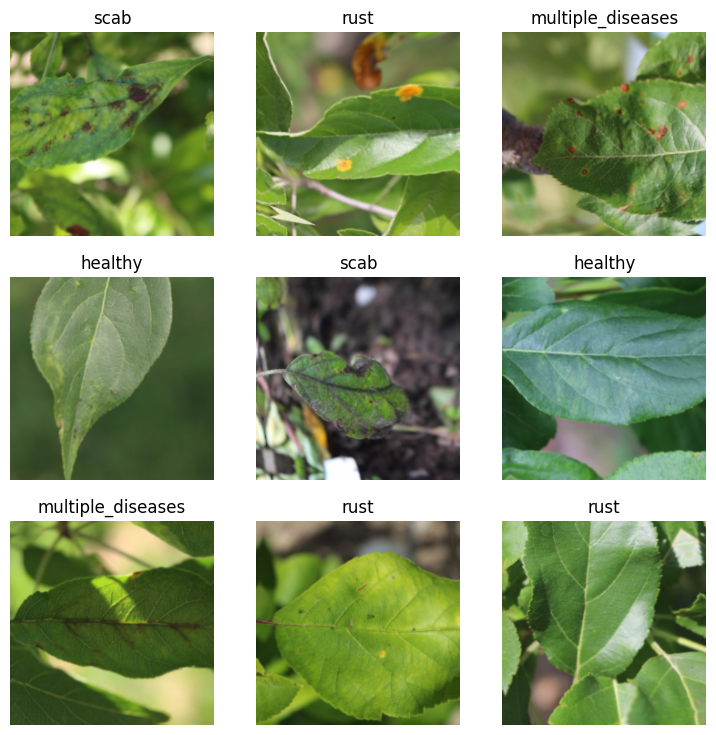

In [12]:
dls = dblock.dataloaders(train_df, bs=BS)
dls.show_batch()



In [13]:
from sklearn.metrics import roc_auc_score


def roc_auc(preds, targs, labels=range(4)):
    # fastai gives class indices for CategoryBlock targets; convert to one-hot for per-class AUC
    targs = np.eye(4)[targs]
    return np.mean([roc_auc_score(targs[:, i], preds[:, i]) for i in labels])


def healthy_roc_auc(*args):
    return roc_auc(*args, labels=[0])


def multiple_diseases_roc_auc(*args):
    return roc_auc(*args, labels=[1])


def rust_roc_auc(*args):
    return roc_auc(*args, labels=[2])


def scab_roc_auc(*args):
    return roc_auc(*args, labels=[3])




In [14]:
metric = partial(AccumMetric, flatten=False)

learn = cnn_learner(
    dls,
    resnet152,
    metrics=[
        error_rate,
        metric(healthy_roc_auc),
        metric(multiple_diseases_roc_auc),
        metric(rust_roc_auc),
        metric(scab_roc_auc),
        metric(roc_auc),
    ],
).to_fp16()



/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth
100%|██████████| 230M/230M [00:02<00:00, 89.8MB/s]


In [15]:
lr = 3e-3



In [16]:
learn.fine_tune(4, lr)



epoch,train_loss,valid_loss,error_rate,healthy_roc_auc,multiple_diseases_roc_auc,rust_roc_auc,scab_roc_auc,roc_auc,time
0,1.600215,0.806817,0.259939,0.897706,0.559061,0.963736,0.926446,0.836738,00:12


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

epoch,train_loss,valid_loss,error_rate,healthy_roc_auc,multiple_diseases_roc_auc,rust_roc_auc,scab_roc_auc,roc_auc,time
0,0.909989,0.553153,0.165138,0.933687,0.542521,0.970370,0.962907,0.852371,00:11
1,0.733137,0.474913,0.128440,0.967077,0.548094,0.985999,0.972679,0.868462,00:12
2,0.580236,0.405962,0.097859,0.983008,0.617224,0.989133,0.982402,0.892942,00:13
3,0.493928,0.407653,0.100917,0.982880,0.634214,0.990110,0.981429,0.897158,00:14


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

In [17]:
test_df = pd.read_csv(path / "test.csv")
test_df.head()



,image_id
0,Test_0
1,Test_1
2,Test_2
3,Test_3
4,Test_4


In [18]:
# Fix: ensure test_dl can build items using the same get_x as training by passing the image_id column.
# Using test_df directly is OK because get_x reads column 0 ("image_id") and appends pref/suff.
tst_dl = learn.dls.test_dl(test_df)



In [19]:
preds, _ = learn.get_preds(dl=tst_dl)
preds.shape



/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


torch.Size([183, 4])

In [20]:
subm = pd.read_csv(path / "sample_submission.csv")

# Fix: assign numpy array to avoid dtype issues; keep full precision (no %.2f rounding) for better AUC.
subm[LABEL_COLS] = preds.numpy()

# Safety: ensure correct column order
subm = subm[["image_id"] + LABEL_COLS]

subm.to_csv("submission.csv", index=False)



In [21]:
pd.read_csv("submission.csv").head()

,image_id,healthy,multiple_diseases,rust,scab
0,Test_0,4.709404e-05,4.322883e-03,8.794386e-08,9.956299e-01
1,Test_1,6.308888e-05,4.442531e-06,4.905641e-09,9.999324e-01
2,Test_2,4.376470e-07,1.226763e-03,9.987726e-01,2.333423e-07
3,Test_3,8.035893e-05,1.189837e-03,9.987279e-01,1.953664e-06
4,Test_4,4.001747e-13,9.060133e-08,9.999999e-01,2.470594e-12
